In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")  

historical = pd.read_csv("MPS_Borough_Level_Crime_Historical.csv")
recent = pd.read_csv("MPS_Borough_Level_Crime_Recent_24_month.csv")
newest = pd.read_csv("MPS_Borough_Level_Crime _Most_Recent_24_months_new.csv")

id_cols_old = ["MajorText", "MinorText", "BoroughName"]
hist_long = historical.melt(id_vars=id_cols_old, var_name="YearMonth", value_name="CrimeCount")
recent_long = recent.melt(id_vars=id_cols_old, var_name="YearMonth", value_name="CrimeCount")

id_cols_new = ["Group", "SubGroup", "BOCU"]
newest_long = newest.melt(id_vars=id_cols_new, var_name="YearMonth", value_name="CrimeCount")
newest_long = newest_long.rename(columns={"BOCU": "BoroughName", "Group": "MajorText", "SubGroup": "MinorText"})

crime = pd.concat([hist_long, recent_long, newest_long], ignore_index=True)

not_boroughs = ["Unknown", "London Heathrow and London City Airports"]
crime = crime[~crime["BoroughName"].isin(not_boroughs)]
crime["Date"] = pd.to_datetime(crime["YearMonth"], format="%Y%m")
crime = crime.sort_values("Date").drop_duplicates(subset=["BoroughName", "MajorText", "MinorText", "Date"], keep="last")

boroughs = sorted(crime["BoroughName"].unique())
print("Number of boroughs:", len(boroughs))

Number of boroughs: 32


In [2]:
results = []

for borough in boroughs:
    borough_series = crime[crime["BoroughName"] == borough].groupby("Date")["CrimeCount"].sum().sort_index()
    borough_series = borough_series.asfreq("MS")

    train = borough_series[:"2026-02-01"]
    test = borough_series["2026-03-01":"2026-06-01"]

    try:
        model = SARIMAX(train, order=(1, 1, 0), seasonal_order=(1, 1, 0, 12))
        fitted = model.fit(disp=False)
        forecast = fitted.get_forecast(steps=4).predicted_mean

        mae = np.mean(np.abs(test.values - forecast.values))
        pct_error = np.mean(np.abs(test.values - forecast.values) / test.values) * 100

        results.append({
            "Borough": borough,
            "Avg_Actual": test.mean().round(0),
            "MAE": mae.round(0),
            "Pct_Error": pct_error.round(1)
        })
        print(f"{borough}: {pct_error:.1f}% error")

    except Exception as e:
        print(f"{borough}: FAILED - {e}")

results_df = pd.DataFrame(results).sort_values("Pct_Error")
print()
print(results_df.to_string(index=False))

Barking and Dagenham: 4.7% error
Barnet: 4.3% error
Bexley: 5.9% error
Brent: 4.9% error
Bromley: 4.6% error
Camden: 6.1% error
Croydon: 3.5% error
Ealing: 5.1% error
Enfield: 2.5% error
Greenwich: 6.9% error
Hackney: 3.5% error
Hammersmith and Fulham: 4.8% error
Haringey: 6.2% error
Harrow: 2.8% error
Havering: 1.7% error
Hillingdon: 5.2% error
Hounslow: 1.5% error
Islington: 4.8% error
Kensington and Chelsea: 1.0% error
Kingston upon Thames: 3.5% error
Lambeth: 3.2% error
Lewisham: 3.1% error
Merton: 1.8% error
Newham: 1.9% error
Redbridge: 2.3% error
Richmond upon Thames: 10.6% error
Southwark: 2.7% error
Sutton: 5.7% error
Tower Hamlets: 4.2% error
Waltham Forest: 8.6% error
Wandsworth: 3.8% error
Westminster: 9.1% error

               Borough  Avg_Actual   MAE  Pct_Error
Kensington and Chelsea      1650.0  17.0        1.0
              Hounslow      2291.0  34.0        1.5
              Havering      1710.0  31.0        1.7
                Merton      1115.0  20.0        1.8
    

Correlation between average crime volume and % error: 0.104


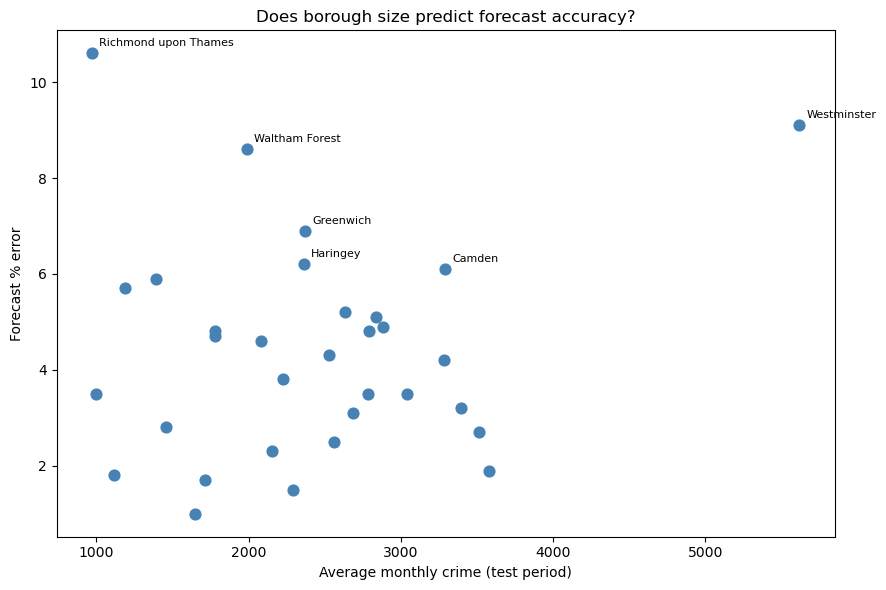

In [3]:
import matplotlib.pyplot as plt

correlation = results_df["Avg_Actual"].corr(results_df["Pct_Error"])
print("Correlation between average crime volume and % error:", correlation.round(3))

plt.figure(figsize=(9, 6))
plt.scatter(results_df["Avg_Actual"], results_df["Pct_Error"], s=60, color="steelblue")
for _, row in results_df.iterrows():
    if row["Pct_Error"] > 6 or row["Avg_Actual"] > 5000:
        plt.annotate(row["Borough"], (row["Avg_Actual"], row["Pct_Error"]), fontsize=8, xytext=(5,5), textcoords="offset points")

plt.xlabel("Average monthly crime (test period)")
plt.ylabel("Forecast % error")
plt.title("Does borough size predict forecast accuracy?")
plt.tight_layout()
plt.savefig("figures/15_borough_size_vs_error.png", dpi=150)
plt.show()

In [4]:
results_df.to_csv("data/borough_forecast_validation_all32.csv", index=False)
print("Saved!")
print()
print("Summary stats:")
print(results_df["Pct_Error"].describe())

Saved!

Summary stats:
count    32.000000
mean      4.390625
std       2.243465
min       1.000000
25%       2.775000
50%       4.250000
75%       5.325000
max      10.600000
Name: Pct_Error, dtype: float64


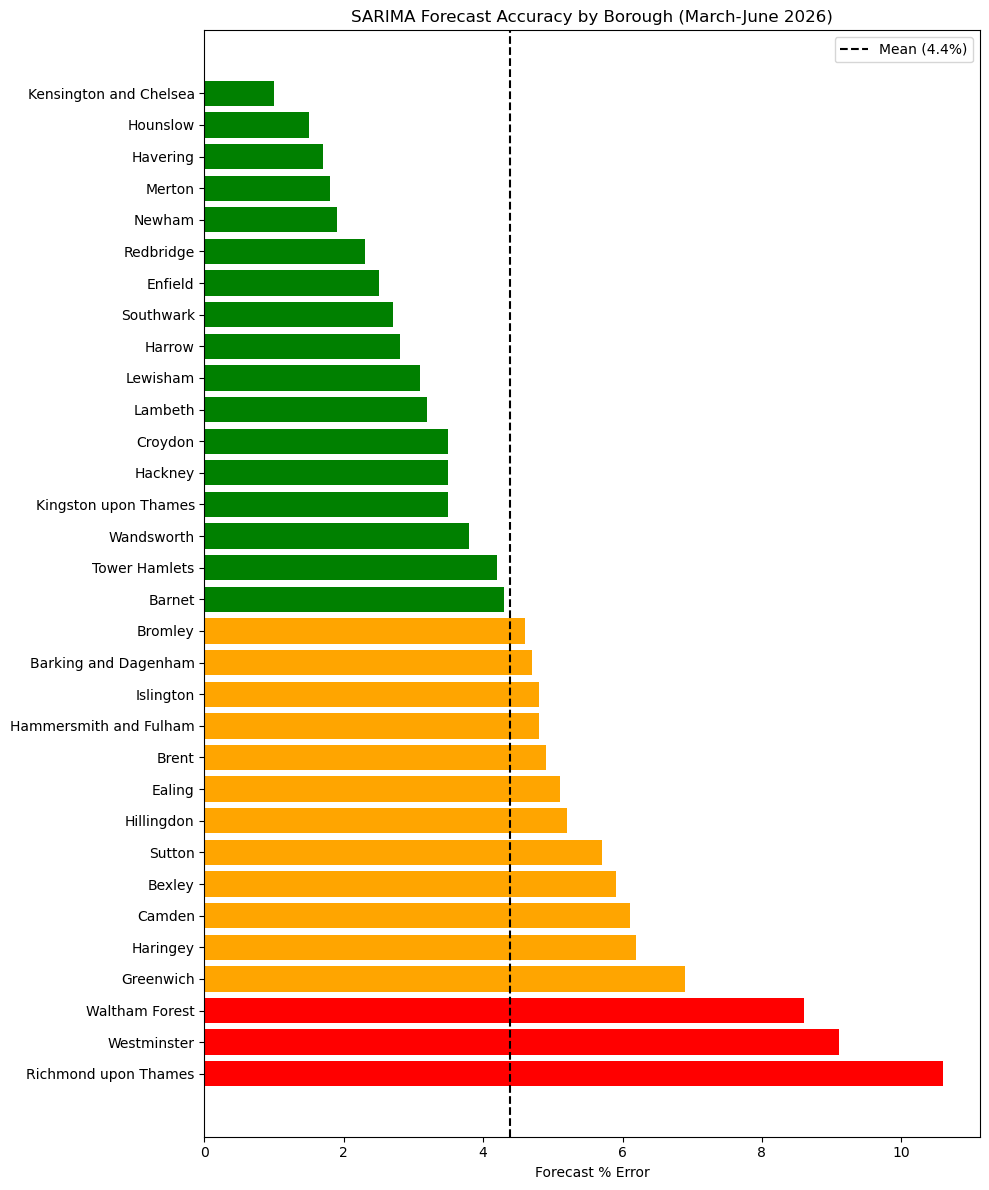

In [5]:
plt.figure(figsize=(10, 12))
colors = ["green" if x < 4.4 else "orange" if x < 7 else "red" for x in results_df["Pct_Error"]]
plt.barh(results_df["Borough"], results_df["Pct_Error"], color=colors)
plt.axvline(results_df["Pct_Error"].mean(), color="black", linestyle="--", label=f"Mean ({results_df['Pct_Error'].mean():.1f}%)")
plt.xlabel("Forecast % Error")
plt.title("SARIMA Forecast Accuracy by Borough (March-June 2026)")
plt.gca().invert_yaxis()  # best borough at top
plt.legend()
plt.tight_layout()
plt.savefig("figures/16_borough_accuracy_ranked.png", dpi=150)
plt.show()

In [6]:
future_results = []

for borough in boroughs:
    borough_series = crime[crime["BoroughName"] == borough].groupby("Date")["CrimeCount"].sum().sort_index()
    borough_series = borough_series.asfreq("MS")

    try:
        model = SARIMAX(borough_series, order=(1, 1, 0), seasonal_order=(1, 1, 0, 12))
        fitted = model.fit(disp=False)

        forecast_result = fitted.get_forecast(steps=6)
        forecast = forecast_result.predicted_mean
        conf_int = forecast_result.conf_int(alpha=0.05)

        for i, date in enumerate(forecast.index):
            future_results.append({
                "Borough": borough,
                "Month": date.strftime("%Y-%m"),
                "Forecast": round(forecast.values[i]),
                "Lower_95CI": round(conf_int.iloc[i, 0]),
                "Upper_95CI": round(conf_int.iloc[i, 1])
            })

        print(f"{borough}: done")

    except Exception as e:
        print(f"{borough}: FAILED - {e}")

future_df = pd.DataFrame(future_results)
print()
print(future_df.head(12))
print()
print("Total rows:", len(future_df))

Barking and Dagenham: done
Barnet: done
Bexley: done
Brent: done
Bromley: done
Camden: done
Croydon: done
Ealing: done
Enfield: done
Greenwich: done
Hackney: done
Hammersmith and Fulham: done
Haringey: done
Harrow: done
Havering: done
Hillingdon: done
Hounslow: done
Islington: done
Kensington and Chelsea: done
Kingston upon Thames: done
Lambeth: done
Lewisham: done
Merton: done
Newham: done
Redbridge: done
Richmond upon Thames: done
Southwark: done
Sutton: done
Tower Hamlets: done
Waltham Forest: done
Wandsworth: done
Westminster: done

                 Borough    Month  Forecast  Lower_95CI  Upper_95CI
0   Barking and Dagenham  2026-07      1930        1709        2152
1   Barking and Dagenham  2026-08      1810        1536        2085
2   Barking and Dagenham  2026-09      1872        1545        2200
3   Barking and Dagenham  2026-10      1975        1604        2346
4   Barking and Dagenham  2026-11      1968        1558        2378
5   Barking and Dagenham  2026-12      1781      

In [7]:
pivot_table = future_df.pivot(index="Borough", columns="Month", values="Forecast")
pivot_table = pivot_table.sort_values("2026-07", ascending=False)

print(pivot_table)

future_df.to_csv("data/borough_future_forecasts_Jul-Dec_2026.csv", index=False)
pivot_table.to_csv("data/borough_future_forecasts_pivot.csv")
print()
print("Saved both files!")

Month                   2026-07  2026-08  2026-09  2026-10  2026-11  2026-12
Borough                                                                     
Westminster                5921     5618     5095     6064     6873     7153
Newham                     3834     3671     3652     4007     3753     3707
Southwark                  3810     3849     3821     4096     3805     3715
Tower Hamlets              3776     3880     3497     3633     3519     3327
Lambeth                    3755     3665     3530     3580     3353     3311
Camden                     3646     3313     3326     3515     3549     3344
Croydon                    3349     3370     3123     3196     3092     3064
Brent                      3131     2880     2841     2989     2741     2555
Ealing                     3130     2833     2766     3011     3017     2735
Hillingdon                 3053     2891     2711     2816     2811     2637
Hackney                    3041     3060     2933     3016     2883     2720

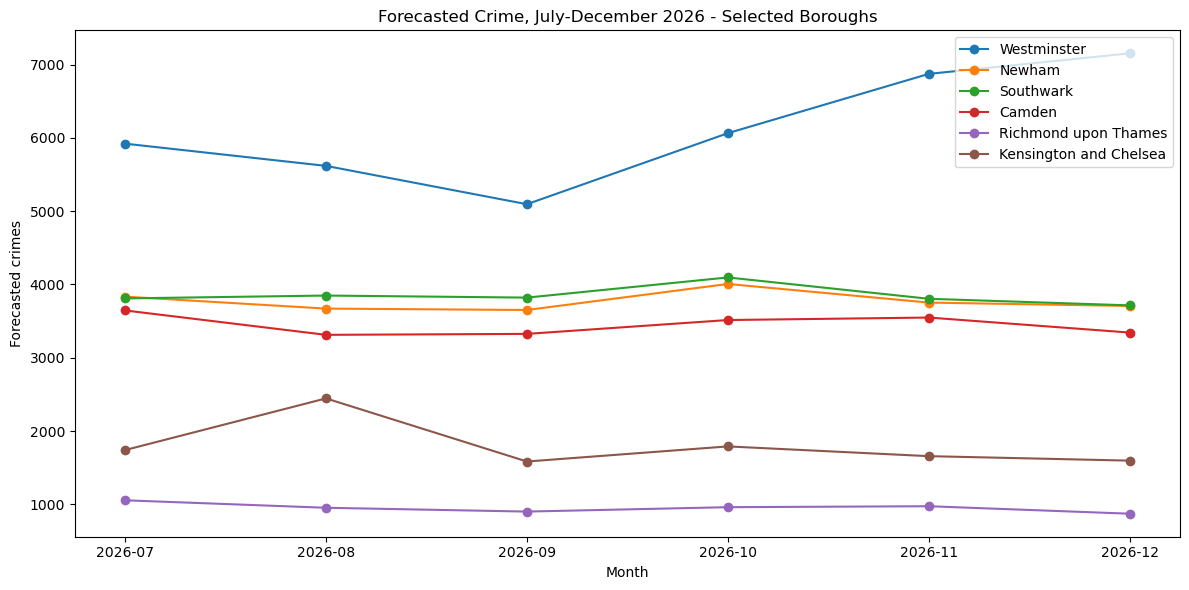

In [8]:
import matplotlib.pyplot as plt

key_boroughs = ["Westminster", "Newham", "Southwark", "Camden", "Richmond upon Thames", "Kensington and Chelsea"]

plt.figure(figsize=(12, 6))
for borough in key_boroughs:
    subset = future_df[future_df["Borough"] == borough]
    plt.plot(subset["Month"], subset["Forecast"], marker="o", label=borough)

plt.title("Forecasted Crime, July-December 2026 - Selected Boroughs")
plt.xlabel("Month")
plt.ylabel("Forecasted crimes")
plt.legend()
plt.tight_layout()
plt.savefig("figures/17_key_borough_forecasts.png", dpi=150)
plt.show()